# 01 — Dataset analysis

What is in BreastDCEDL, before anything is generated from it. Read this first.

**Responsibility:** describe the raw metadata. Writes no images and trains nothing.

| | |
|---|---|
| source | [Zenodo 18114231](https://zenodo.org/records/18114231), MinCrop v4 |
| paper | [arXiv:2506.12190](https://arxiv.org/abs/2506.12190) |
| cohorts | I-SPY2 982 · DUKE 916 · I-SPY1 172 = 2,070 patients |

In [ ]:
# Reload edited project modules without restarting the kernel.
#
# Python caches imported modules in sys.modules and never re-reads the file, so
# editing anything under src/ leaves this kernel running the old version - which
# surfaces as an ImportError for a function you can see in the file. These two
# lines must run BEFORE the imports below to cover them.
#
# It is not infallible: it does not update already-instantiated objects whose
# class changed shape. After a long editing session, restart the kernel.
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dataset_config as config
from dataset_config import Config, TASKS

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

In [2]:
meta = pd.read_csv(config.METADATA_CSV)
print(f"{len(meta)} patients, {meta.shape[1]} metadata columns\n")
print(meta.dataset.value_counts().to_string())

2070 patients, 29 metadata columns

dataset
spy2    982
duke    916
spy1    172


## Label availability per cohort

Each task uses a different column, and each column is missing for a different set
of patients. This table decides how many patients each experiment can use.

In [3]:
rows = []
for name, spec in TASKS.items():
    for cohort, g in meta.groupby("dataset"):
        rows.append({"task": name, "column": spec.column, "cohort": cohort,
                     "available": int(g[spec.column].notna().sum()), "total": len(g)})
avail = pd.DataFrame(rows).pivot_table(index=["task", "column"], columns="cohort",
                                       values="available")
print(avail.to_string())
print("\npCR is the limiting one: DUKE has it for only 298 of 916 patients.")

cohort                   duke   spy1   spy2
task    column                             
her2    HER2            916.0  167.0  982.0
hr      HR              916.0  170.0  982.0
pcr     pCR             298.0  172.0  982.0
subtype HR_HER2_STATUS  916.0  167.0  982.0

pCR is the limiting one: DUKE has it for only 298 of 916 patients.


## The official split

The `test` column of the metadata: 0 = train, 1 = test, 2 = validation. Using it
rather than a new split is what makes any result comparable with the published
ones.

In [4]:
split_names = {0: "train", 1: "test", 2: "val"}
m = meta.assign(split=meta.test.map(split_names))
print(pd.crosstab(m.dataset, m.split, margins=True).to_string())
print()
print(pd.crosstab(m.split, m.HR_HER2_STATUS, margins=True).to_string())

split    test  train  val   All
dataset                        
duke      136    644  136   916
spy1       35    104   33   172
spy2       99    784   99   982
All       270   1532  268  2070

HR_HER2_STATUS  HER2pos  HRposHER2neg  TripleNeg   All
split                                                 
test                 53           137         78   268
train               346           773        410  1529
val                  60           132         76   268
All                 459          1042        564  2065


## The cohorts are not interchangeable

This is the single most important fact about this dataset, and it constrains
every design decision downstream.

A model trained on pooled cohorts can answer *"which scanner produced this?"*
instead of *"which subtype is this?"*. Measured on exactly this data: a source
probe — the identical pipeline with the cohort as the label — reaches
**patient-level macro-AUC 0.9978**, while the subtype task sits at 0.61.

In [5]:
m2 = meta[meta.HR_HER2_STATUS.notna()].copy()
m2["box_side_px"] = np.maximum(m2.ecol - m2.scol, m2.eraw - m2.sraw)
m2["box_side_mm"] = m2.box_side_px * m2.xy_spacing

summary = m2.groupby("dataset").agg(
    patients=("pid", "size"),
    HRposHER2neg_pct=("HR_HER2_STATUS", lambda s: round(100 * (s == "HRposHER2neg").mean(), 1)),
    tumour_mm_median=("box_side_mm", lambda s: round(s.median(), 1)),
    tumour_volume_median=("tum_vol", lambda s: round(s.median(), 2)),
    xy_spacing_median=("xy_spacing", lambda s: round(s.median(), 3)))
print(summary.to_string())
print()
print("DUKE tumours are ~5x smaller by volume and its majority class is 26 points")
print("more frequent. 'small tumour -> DUKE -> HRposHER2neg' is available as a shortcut.")

         patients  HRposHER2neg_pct  tumour_mm_median  tumour_volume_median  xy_spacing_median
dataset                                                                                       
duke          916              64.6              29.2                  2.82              0.703
spy1          167              41.3              64.8                 15.19              0.781
spy2          982              38.8              61.2                 14.72              0.684

DUKE tumours are ~5x smaller by volume and its majority class is 26 points
more frequent. 'small tumour -> DUKE -> HRposHER2neg' is available as a shortcut.


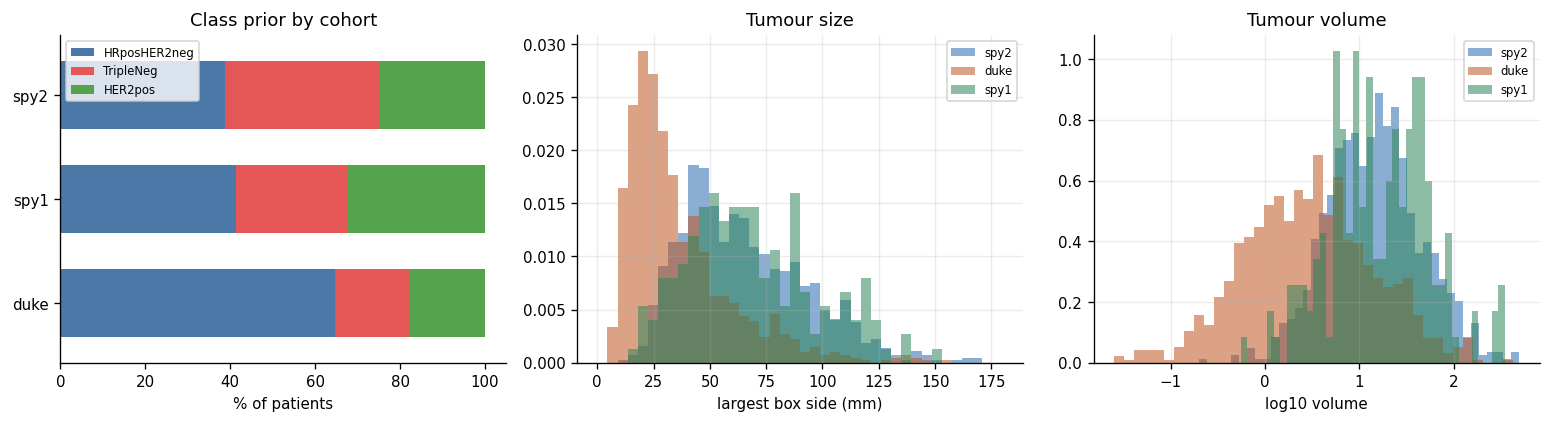

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
colours = {"spy2": "#2b6cb0", "duke": "#c05621", "spy1": "#2f855a"}

prop = pd.crosstab(m2.dataset, m2.HR_HER2_STATUS, normalize="index") * 100
prop[["HRposHER2neg", "TripleNeg", "HER2pos"]].plot(
    kind="barh", stacked=True, ax=ax[0], width=0.65,
    color=["#4c78a8", "#e45756", "#54a24b"])
ax[0].set_title("Class prior by cohort"); ax[0].set_xlabel("% of patients")
ax[0].set_ylabel(""); ax[0].legend(fontsize=7); ax[0].grid(False)

for c in colours:
    ax[1].hist(m2[m2.dataset == c].box_side_mm, bins=40, range=(0, 180), alpha=0.55,
               density=True, color=colours[c], label=c)
ax[1].set_title("Tumour size"); ax[1].set_xlabel("largest box side (mm)")
ax[1].legend(fontsize=7)

for c in colours:
    ax[2].hist(np.log10(m2[m2.dataset == c].tum_vol.clip(lower=0.01)), bins=40,
               alpha=0.55, density=True, color=colours[c], label=c)
ax[2].set_title("Tumour volume"); ax[2].set_xlabel("log10 volume"); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

## What this means for the two pipelines

* **Authors' pipeline** pools all three cohorts, because that is what they did and
  the comparison must be like for like.
* **My pipeline** defaults to I-SPY2 alone. Pooling would let the shortcut above
  inflate every number.

Whenever cohorts are pooled, the source probe must be run and reported beside the
result. Notebook `06` does that in one line.